### **Model Validation Using Train-Test Split**
example on a 2d dataset doing a 60/20/20 (train-validate-test)

In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set(style='darkgrid')

In [94]:
### generate synthetic sample data
np.random.seed(33)
points = np.random.rand(100, 2)
df = pd.DataFrame(points, columns=['x', 'y'])

### assign train(60%), test(20%), validate(20%) labels
labels = ['train']*60 + ['validate']*20 + ['test']*20
np.random.shuffle(labels)
df['set'] = labels

df.head()

,x,y,set
0,0.248510,0.449975,validate
1,0.410941,0.260300,test
2,0.870396,0.185040,train
3,0.019661,0.953252,validate
4,0.680451,0.486588,test


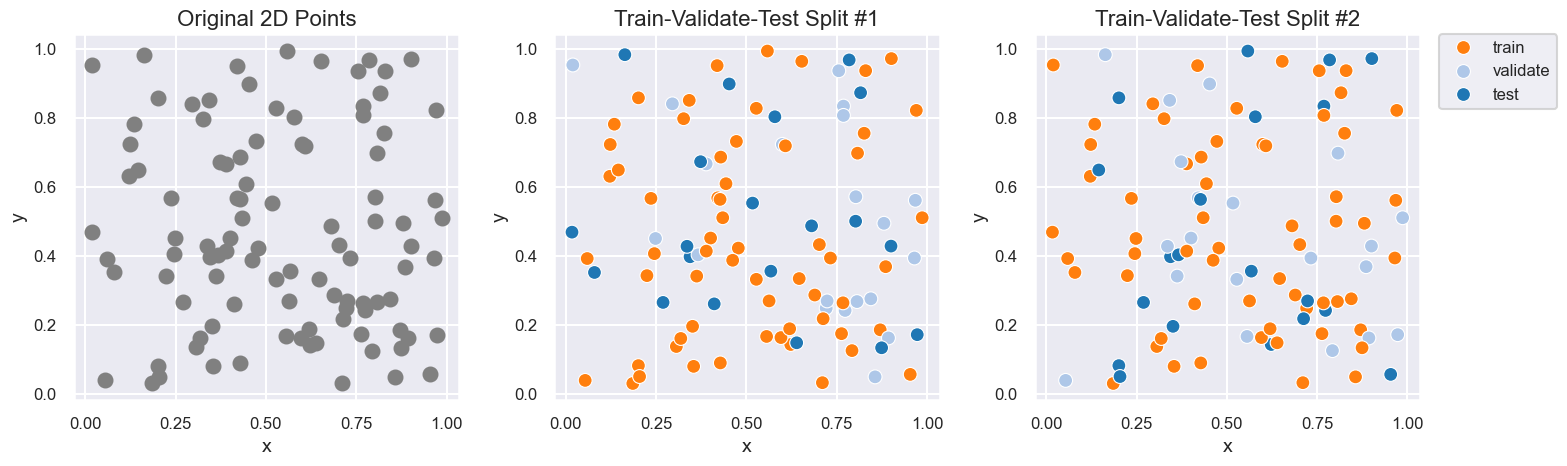

In [95]:
### generate plot with two train-validate-test splits
sns.set_context('talk')
marker_size = 100

### get first 3 colors from a palette
tab20_colors = sns.color_palette('tab20', 3)

### create palette dict
palette_dict = {
    'test': tab20_colors[0],
    'validate': tab20_colors[1],
    'train': tab20_colors[2]
}

### plot before and after labeling
plt.figure(figsize=(16, 5))

### before labeling
plt.subplot(1, 3, 1)
plt.scatter(df['x'], df['y'], color='gray', s=marker_size)
plt.title('Original 2D Points', fontsize=16)
plt.xlabel('x', fontsize=14)
plt.ylabel('y', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

### after labeling -- train-validate-test split #1
plt.subplot(1, 3, 2)
sns.scatterplot(data=df, x='x', y='y', hue='set', palette=palette_dict, s=marker_size)
plt.title('Train-Validate-Test Split #1', fontsize=16)
plt.xlabel('x', fontsize=14)
plt.ylabel('y', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend().remove()

### assign different labels to each data item
np.random.shuffle(labels)
df['set'] = labels

### after labeling -- train-validate-test split #2
plt.subplot(1, 3, 3)
sns.scatterplot(data=df, x='x', y='y', hue='set', palette=palette_dict, s=marker_size)
plt.title('Train-Validate-Test Split #2', fontsize=16)
plt.xlabel('x', fontsize=14)
plt.ylabel('y', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title_fontsize='13', fontsize='12', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.show()

### **Train-Validate-Test Split Using Scikit-Learn:**

In [96]:
### synthetic dataset using sklearn's make_regression
n_samples = 1000

X, y = make_regression(n_samples,
                       n_features=1,
                       noise=10,
                       bias=50,
                       random_state=33
                      )

# convert to dataframe
if (X.shape[1] ==1):
    feature_names = ['X']
else:
    feature_names = [f'X{i+1}' for i in range(X.shape[1])]

df = pd.DataFrame(X, columns=feature_names)
df['y'] = y
df.head()

,X,y
0,-0.628362,52.767796
1,0.153254,59.613956
2,0.774163,56.969242
3,-0.050919,50.788951
4,-1.211403,42.589608


In [97]:
### train-validate-test split
X_train, X_test, y_train, y_test = train_test_split(df[['X']], # X data points; can be multiple X variables
                                                    df['y'], # y data points
                                                    test_size=0.4, # train-test split = 60-40
                                                    random_state=42
                                                    )

In [98]:
print('Original dataset size:', X.shape)
print('Train dataset size:   ', X_train.shape)
print('Test dataset size:    ', X_test.shape)

Original dataset size: (1000, 1)
Train dataset size:    (600, 1)
Test dataset size:     (400, 1)


Scikit-learn's train_test_split( ) only splits into two sets. Since we want to do a 60/20/20 train-validate-test we can recursively call it again, to split the test set into a validate and new test set.

In [99]:
X_validate, X_test2, y_validate, y_test2 = train_test_split(X_test,
                                                            y_test,
                                                            test_size=0.5, # splitting the test in half to get 20/20
                                                            random_state=33
                                                           )

In [100]:
print('Original dataset size:  ', X.shape)
print('Train dataset size:     ', X_train.shape)
print('Old test dataset size:  ', X_test.shape)
print('New test dataset size:  ', X_test2.shape)
print('Validation dataset size:', X_validate.shape)

Original dataset size:   (1000, 1)
Train dataset size:      (600, 1)
Old test dataset size:   (400, 1)
New test dataset size:   (200, 1)
Validation dataset size: (200, 1)


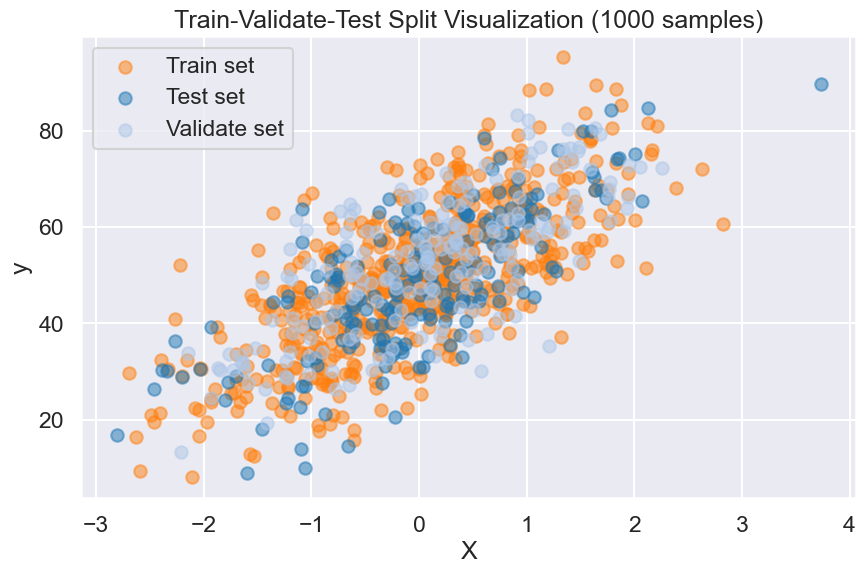

In [101]:
### visualize the split
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color=palette_dict['train'], label='Train set', alpha=0.5)
plt.scatter(X_test2, y_test2, color=palette_dict['test'], label='Test set', alpha=0.5)
plt.scatter(X_validate, y_validate, color=palette_dict['validate'], label='Validate set', alpha=0.5)
plt.xlabel('X')
plt.ylabel('y')
plt.title(f'Train-Validate-Test Split Visualization ({n_samples} samples)')
plt.legend()
plt.grid(True)
plt.show()

### **Machine Learning Pipeline:**
We assume the data has been stored in a df DataFrame. For simplicity, we only perform a train-test split (no validation), with an 80-20 ratio

In [102]:
myseed_list = [1, 7, 90, 170, 457, 3489, 5409, 6700, 9999, 10798]
myseed_len = len(myseed_list)

x = df[['X']] # can hold multiple x variables in a multivariate case
y = df['y']

### function to run pipeline repeatedly
def run_pipeline(n_runs=10):
    rmse_list = []
    r2_list = []
    seed_list = []

    for i in range(n_runs):
        # select new seed each run
        myseed = myseed_list[i % myseed_len]

        # split the data differently each time
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=myseed)

        # define pipeline: preprocessing + model
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('regressor', LinearRegression())
        ])

        # fit the pipeline
        pipeline.fit(X_train, y_train)

        # predict and evalute
        y_pred = pipeline.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        rmse_list.append(rmse)
        r2_list.append(r2)
        seed_list.append(myseed)

        print(f'Run {i+1}: seed = {myseed}, RMSE = {rmse:.2f}, R2 = {r2:.2f}')

    return pd.DataFrame({
        'seed': seed_list,
        'RMSE': rmse_list,
        'R2': r2_list
    })

### run the pipeline 10 times and show the results
results_df = run_pipeline(n_runs=10)
results_df

Run 1: seed = 1, RMSE = 10.32, R2 = 0.53
Run 2: seed = 7, RMSE = 11.24, R2 = 0.44
Run 3: seed = 90, RMSE = 9.83, R2 = 0.55
Run 4: seed = 170, RMSE = 11.46, R2 = 0.46
Run 5: seed = 457, RMSE = 10.56, R2 = 0.49
Run 6: seed = 3489, RMSE = 10.20, R2 = 0.53
Run 7: seed = 5409, RMSE = 10.37, R2 = 0.50
Run 8: seed = 6700, RMSE = 10.98, R2 = 0.46
Run 9: seed = 9999, RMSE = 9.56, R2 = 0.57
Run 10: seed = 10798, RMSE = 10.42, R2 = 0.54


,seed,RMSE,R2
0,1,10.322469,0.528379
1,7,11.239251,0.442502
2,90,9.832437,0.554780
3,170,11.464661,0.460492
4,457,10.555435,0.488222
5,3489,10.202662,0.525564
6,5409,10.365216,0.502410
7,6700,10.982606,0.460965
8,9999,9.557375,0.570564
9,10798,10.418573,0.536978


### Comparison of Performance Without Splits:

In [103]:
# train and evaluate on the entire dataset
model_all = LinearRegression()
model_all.fit(df[['X']], df['y'])
y_pred_all = model_all.predict(df[['X']])

# evaluate RMSE and R2
rmse_all = np.sqrt(mean_squared_error(df['y'], y_pred_all))
r2_all = r2_score(df['y'], y_pred_all)

print(f'All Data RMSE (train on all data): {rmse_all:.4f}')
print(f'All Data R^2 (train on all data): {r2_all:.4f}')

All Data RMSE (train on all data): 10.1962
All Data R^2 (train on all data): 0.5208


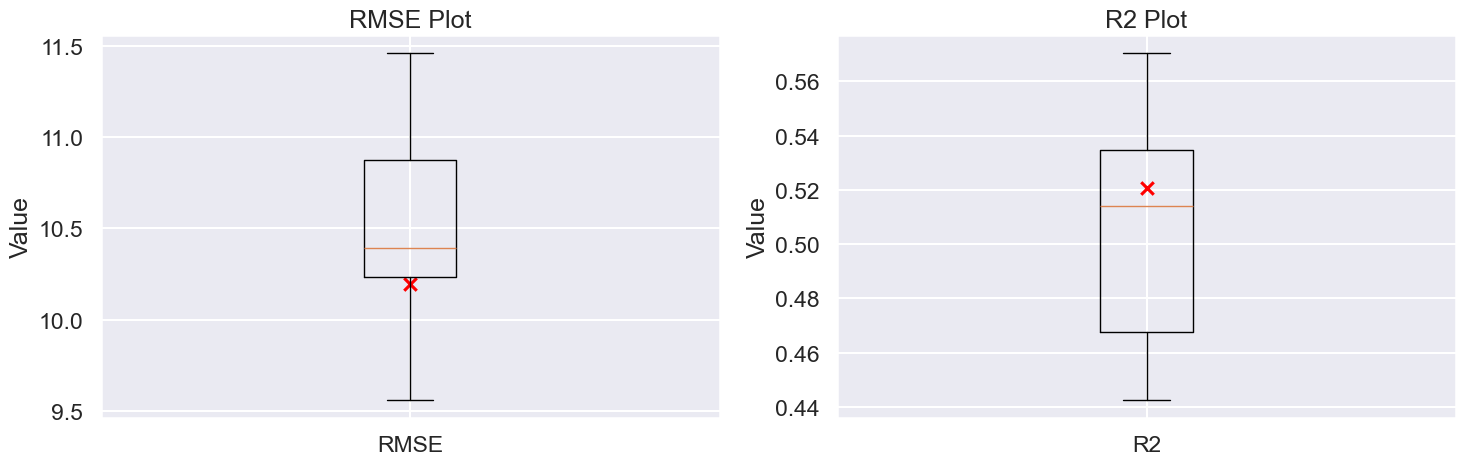

In [104]:
### visualize with boxplots
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# boxplot for RMSE
ax[0].boxplot(results_df['RMSE'])
ax[0].scatter(1, rmse_all, color='red', marker='x', label='ALL DATA')
ax[0].set_title('RMSE Plot')
ax[0].set_ylabel('Value')
ax[0].set_xticks([1])
ax[0].set_xticklabels(['RMSE'])

# boxplot for R2
ax[1].boxplot(results_df['R2'])
ax[1].scatter(1, r2_all, color='red', marker='x', label='ALL DATA')
ax[1].set_title('R2 Plot')
ax[1].set_ylabel('Value')
ax[1].set_xticks([1])
ax[1].set_xticklabels(['R2'])

plt.tight_layout()
plt.show()

The box plots summarize all the RMSE/R2 data over 10 runs, using different train-test splits. The linear regression model is trained on the training data and evaluated on the test data. This provides a good estimate of how well the model will perform on new, unseen data. The two red cross points correspond to the RMSE/R2 values for training on the entire dataset and also evaluating on the entire dataset. This approach can be overly optimistic because the model is evaluated on the same data it was trained on. Always evaluate model performance on held-out test data to avoid overfitting.

### Trying Different Train-Test Percentages:
* 50/50
* 60/40
* 70/30
* 75/25
* 80/20
* 85/15
* 90/10
* 95/5
* 98/2
* 99/1

In [105]:
mytest_list = [0.50, 0.40, 0.30, 0.25, 0.20, 0.15, 0.10, 0.05, 0.02, 0.01]
mytest_len = len(mytest_list)

x = df[['X']] # can hold multiple x variables in a multivariate case
y = df['y']

### function to run pipeline repeatedly
def run_pipeline(n_runs=10):
    rmse_list = []
    r2_list = []
    test_list = []

    for i in range(n_runs):
        # select new test each run
        mytest = mytest_list[i % mytest_len]

        # split the data differently each time
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=mytest, random_state=33)

        # define pipeline: preprocessing + model
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('regressor', LinearRegression())
        ])

        # fit the pipeline
        pipeline.fit(X_train, y_train)

        # predict and evalute
        y_pred = pipeline.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        rmse_list.append(rmse)
        r2_list.append(r2)
        test_list.append(mytest)

        print(f'Run {i+1}: test = {mytest}, RMSE = {rmse:.2f}, R2 = {r2:.2f}')

    return pd.DataFrame({
        'test': test_list,
        'RMSE': rmse_list,
        'R2': r2_list
    })

### run the pipeline 10 times and show the results
results_df = run_pipeline(n_runs=10)
results_df

Run 1: test = 0.5, RMSE = 10.07, R2 = 0.51
Run 2: test = 0.4, RMSE = 10.03, R2 = 0.51
Run 3: test = 0.3, RMSE = 9.73, R2 = 0.53
Run 4: test = 0.25, RMSE = 9.54, R2 = 0.53
Run 5: test = 0.2, RMSE = 9.50, R2 = 0.54
Run 6: test = 0.15, RMSE = 9.12, R2 = 0.53
Run 7: test = 0.1, RMSE = 9.91, R2 = 0.47
Run 8: test = 0.05, RMSE = 10.71, R2 = 0.32
Run 9: test = 0.02, RMSE = 12.23, R2 = 0.27
Run 10: test = 0.01, RMSE = 11.52, R2 = 0.05


,test,RMSE,R2
0,0.50,10.073678,0.511330
1,0.40,10.034566,0.509024
2,0.30,9.726673,0.529550
3,0.25,9.542379,0.528462
4,0.20,9.504184,0.536649
5,0.15,9.121257,0.532848
6,0.10,9.907583,0.474220
7,0.05,10.714709,0.316853
8,0.02,12.232693,0.273664
9,0.01,11.517822,0.045570
